<a href="https://colab.research.google.com/github/ushayenumula01-wq/project-1/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
import joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
print(df.head())

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB
None


In [7]:
print(df.tail())

     Age  EstimatedSalary  Purchased
395   46            41000          1
396   51            23000          1
397   50            20000          1
398   36            33000          0
399   49            36000          1


In [8]:
print(df.describe())

              Age  EstimatedSalary   Purchased
count  400.000000       400.000000  400.000000
mean    37.655000     69742.500000    0.357500
std     10.482877     34096.960282    0.479864
min     18.000000     15000.000000    0.000000
25%     29.750000     43000.000000    0.000000
50%     37.000000     70000.000000    0.000000
75%     46.000000     88000.000000    1.000000
max     60.000000    150000.000000    1.000000


In [9]:
print(df.isnull().sum())

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [10]:
df = df.dropna()

In [12]:
print(df.isnull().sum())

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [13]:
print(df.duplicated().sum())

33


In [14]:
print(df.drop_duplicates(inplace= True))      #for Removing the duplicates

None


In [18]:
#     For Encoding the Categorical Columns: there is no any categorical columns like gender in the dataset that I have taken
#There are no categorical columns in this dataset, so encoding is not required.

In [16]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

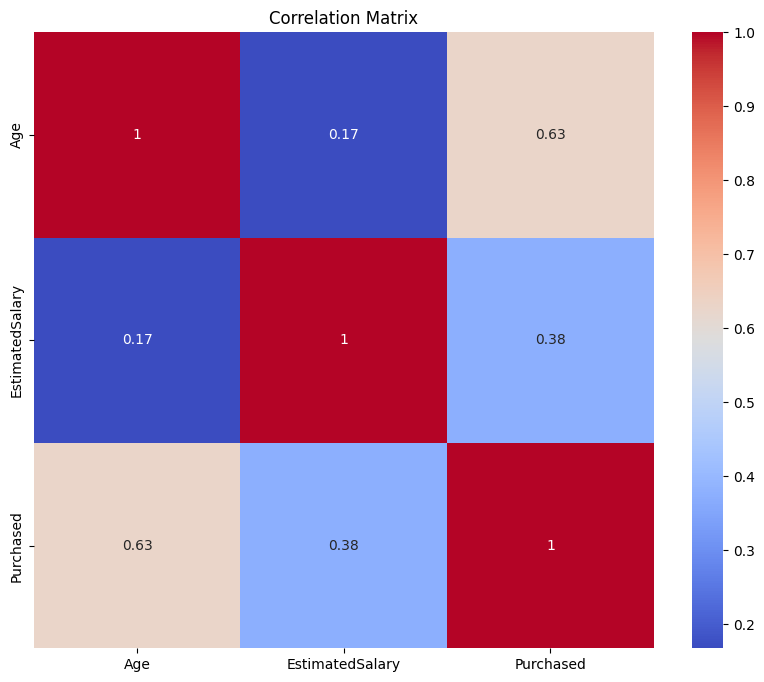

In [21]:
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")     #Correlation Matrix
plt.title("Correlation Matrix")
plt.show()

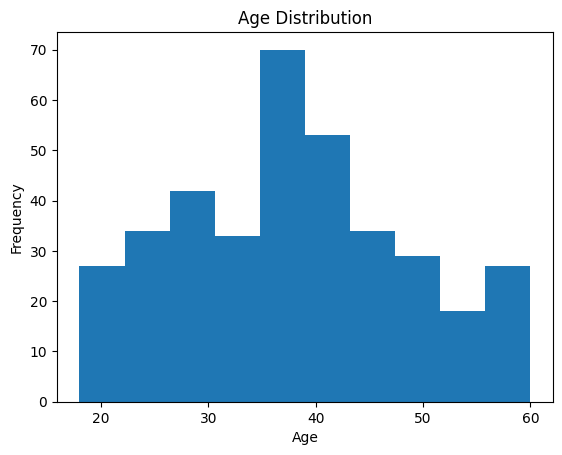

In [23]:
plt.hist(df["Age"],bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")         #Histogram
plt.ylabel("Frequency")
plt.show()

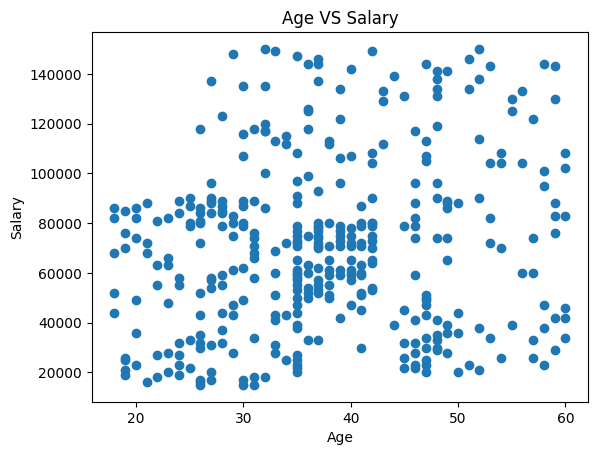

In [24]:
plt.scatter(df["Age"],df["EstimatedSalary"])
plt.title("Age VS Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

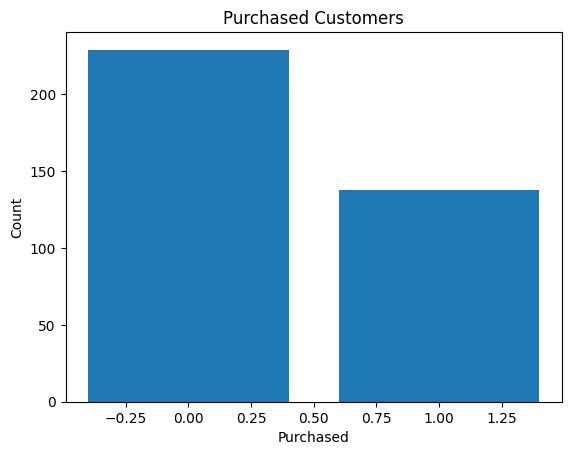

In [33]:
purchase = df["Purchased"].value_counts()
plt.bar(purchase.index, purchase.values)
plt.xlabel("Purchased")
plt.ylabel("Count")
plt.title("Purchased Customers")
plt.show()

In [27]:
X= df[["Age", "EstimatedSalary"]]
y= df["Purchased"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) #Standard Scaler
x_test = scaler.transform(X_test)

In [31]:
IR = LogisticRegression()
IR.fit(X_train, y_train)         #Logistic Regression
IR_pre = IR.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [32]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pre = knn.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [34]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [39]:
models = {
    "Logistic Regression": IR_pre,
    "KNN": knn_pre,
    "Decision Tree": dt_pred
}
for name, pred in models.items():
    print("\n", name)
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))


 Logistic Regression
Accuracy : 0.3783783783783784
Precision: 0.3783783783783784
Recall   : 1.0
F1 Score : 0.5490196078431373

 KNN
Accuracy : 0.3783783783783784
Precision: 0.3783783783783784
Recall   : 1.0
F1 Score : 0.5490196078431373

 Decision Tree
Accuracy : 0.3783783783783784
Precision: 0.3783783783783784
Recall   : 1.0
F1 Score : 0.5490196078431373


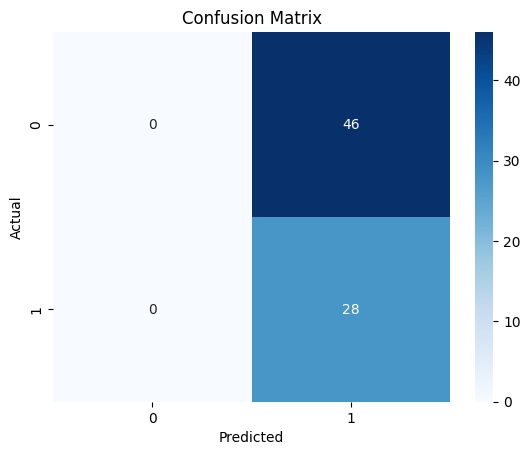

In [41]:
cm = confusion_matrix(y_test, IR_pre)
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

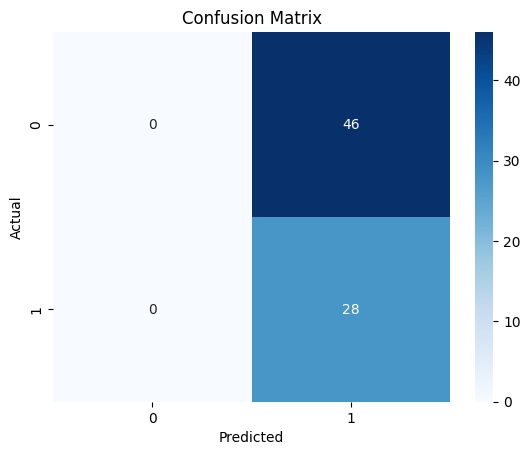

In [42]:
cm = confusion_matrix(y_test, knn_pre)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

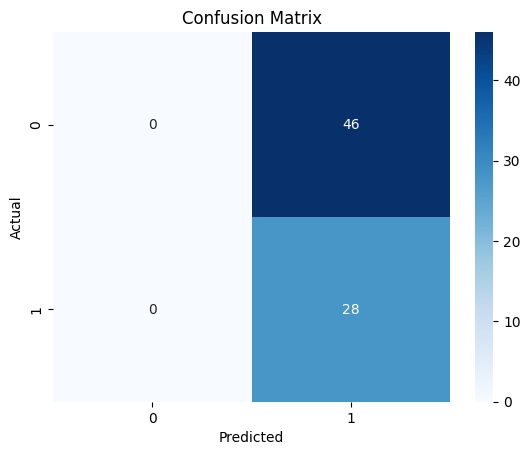

In [43]:
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [44]:
joblib.dump(lr, "best_model.pkl")
print("Model Saved Successfully")

NameError: name 'lr' is not defined

In [46]:
def predict_customer(age, salary):
    data = pd.DataFrame([[age, salary]],
                        columns=["Gender","Age","EstimatedSalary"])
    data = scaler.transform(data)
    result = IR.pre(data)
    if result[0] == 1:
        print("Customer Will Purchase")
    else:
        print("Customer Will Not Purchase")